In [7]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
adata = sc.read('D:/scLT/Weinreb/0814/desc246.1/anndata.h5ad')#'D:/scLT/Weinreb/BiTree/Data/Data.adata/processed_data.h5ad'

In [3]:
# Step 1: 导入数据
# 读取 count 矩阵 (基因表达计数矩阵)
count_matrix = pd.read_csv('D:/scLT/Weinreb/0814/desc2.count.csv', index_col=0)  # 设定 index_col=0，假设行索引为基因
# 读取细胞注释信息
meta_data = pd.read_csv('D:/scLT/Weinreb/0814//desc2.meta.csv', index_col=0)  # 假设每个细胞的元数据都有一个唯一的索引
count_matrix = count_matrix.T
count_matrix.index = 'X'+count_matrix.index.astype(str)
meta_data.index = 'X'+meta_data.index.astype(str)

In [4]:
# Step 2: 创建 AnnData 对象
# AnnData 是 Scanpy 中的核心数据结构，它包含了表达矩阵和元数据
adata = sc.AnnData(X=count_matrix)

# 将元数据（例如细胞类型、实验条件等）添加到 AnnData 对象中
adata.obs = meta_data


In [ ]:
# Step 3: 数据预处理
# 基本的预处理步骤包括筛选低质量细胞和基因，标准化数据等

# 过滤掉低表达的基因和细胞（根据总表达量进行过滤，去除空白或低质量细胞）
sc.pp.filter_cells(adata, min_genes=200)  # 过滤掉表达基因小于 200 的细胞
sc.pp.filter_genes(adata, min_cells=3)    # 过滤掉在少于 3 个细胞中表达的基因

# 计算基因的线粒体基因比例（如果元数据包含该信息）
adata.var['mt'] = adata.var_names.str.startswith('mt-')  # 假设线粒体基因以 "MT-" 开头
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 过滤掉高线粒体基因比例的细胞
adata = adata[adata.obs.pct_counts_mt < 5, :]  # 过滤掉线粒体基因比例超过 5% 的细胞

In [5]:
# Step 4: 标准化数据
sc.pp.normalize_total(adata, target_sum=1e4)  # 每个细胞的总计数标准化为 10000
sc.pp.log1p(adata)  # 对数据进行对数转换

In [6]:
hvg = pd.read_csv('D:/scLT/Weinreb/0814/desc2.hvg.csv', index_col=0).iloc[:,0].values
hvg

array(['S100a9', 'S100a8', 'Ngp', ..., 'Mast4', 'Gm10330', 'Mplkip'],
      dtype=object)

In [91]:
# Step 5: 高度变异基因识别
#sc.pp.highly_variable_genes(adata, min_mean=0.1, max_mean=10, min_disp=0.5)
#adata = adata[:, adata.var.highly_variable]  # 只保留高变基因
#adata = adata[:, hvg] 
# Step 6: 数据降维（PCA）
sc.tl.pca(adata, svd_solver='arpack')  # 进行主成分分析（PCA）

# Step 7: 计算邻接图（用于 t-SNE 和 UMAP）
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=50)  # 计算最近邻，n_pcs 可以根据情况调整#

# Step 8: 使用 t-SNE 或 UMAP 降维
# t-SNE 降维
#sc.tl.tsne(adata, random_state=42)

# 或者选择 UMAP 降维（UMAP 可能会提供更清晰的可视化结果）
sc.tl.umap(adata)

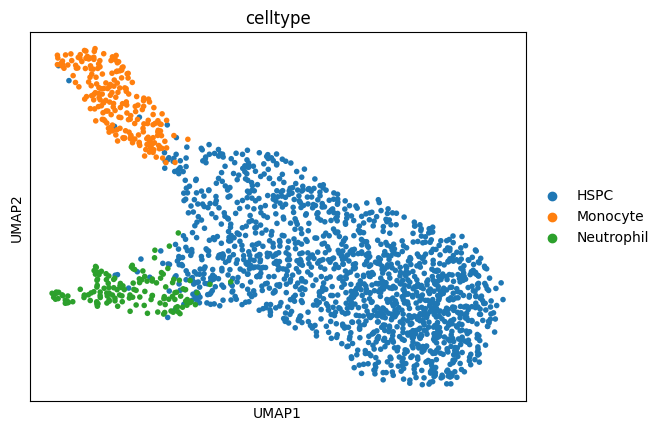

In [8]:
# Step 9: 可视化
# t-SNE 可视化
#sc.pl.tsne(adata, color=['cell_type'], save='_tsne.png')  # 假设元数据中包含 'cell_type' 列
sc.pl.umap(adata, color=['celltype'])

# 还可以展示其他的属性，如基因的表达（假设 'GeneA' 是你感兴趣的基因）
# sc.pl.tsne(adata, color=['GeneA'])

# Step 10: 保存结果
#adata.write('D:/processed_data.h5ad')  # 保存处理后的 AnnData 对象，可以供后续分析使用

In [16]:
# --- 1. 准备数据 ---
adata1 = adata.copy()

# --- 2. 定义一个复杂的分类函数 ---
def categorize_by_louvain(cluster):
    cluster_str = str(cluster) # 确保输入是字符串
    if cluster_str in ['Endoderm','Gut','NLE','PNEC']:
        return 'non_iAEC2'
    elif cluster_str == 'Others':
        return 'Others'
    elif cluster_str =='iAEC2':
        return 'iAEC2'
    else:
        return 'Other'

# --- 3. 应用函数并创建新列 ---
adata1.obs['lineage'] = adata.obs['state_info'].apply(categorize_by_louvain)
adata1.obs['umap_1'] = adata1.obsm['X_umap'][:, 0]

adata1.obs['umap_2'] = adata1.obsm['X_umap'][:, 1]

In [5]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
from scipy.sparse import issparse

def export_adata_subsets_by_group(
    adata: sc.AnnData,
    group_by: str,
    task_name: str,
    output_path: str
) -> list:
    """
    按照 obs 某一列对 adata 对象进行分组，并导出每个组的子集数据。

    对于每个组，函数会提取并保存三个文件：
    1. obs 元数据子集
    2. 高变基因的表达矩阵子集
    3. PCA 嵌入子集（前20个主成分）

    Args:
        adata (sc.AnnData): 已预处理的 AnnData 对象。
                              必须包含 .var['highly_variable'] 和 .obsm['X_pca']。
        group_by (str): adata.obs 中用于分组的列名，例如 'cell_type'。
        task_name (str): 用于文件命名的任务标识符。
        output_path (str): 用于保存输出文件的目录路径。

    Returns:
        list: 一个包含所有已生成文件路径的列表。
        
    Raises:
        ValueError: 如果 group_by 列、highly_variable 标记或 X_pca 结果不存在。
    """
    # --- 1. 安全检查和准备工作 ---
    # 检查分组列是否存在
    if group_by not in adata.obs.columns:
        raise ValueError(f"错误: 分组列 '{group_by}' 在 adata.obs 中不存在。")
        
    # 检查高变基因是否已计算
    if 'highly_variable' not in adata.var.columns:
        raise ValueError("错误: adata.var 中未找到 'highly_variable'。请先运行 sc.pp.highly_variable_genes()。")

    # 检查PCA是否已计算
    if 'X_pca' not in adata.obsm:
        raise ValueError("错误: adata.obsm 中未找到 'X_pca'。请先运行 sc.pp.pca()。")

    # 创建输出目录（如果不存在）
    os.makedirs(output_path, exist_ok=True)
    print(f"文件将被保存到: {os.path.abspath(output_path)}")

    # 获取所有唯一的组
    unique_groups = adata.obs[group_by].unique()
    # 获取高变基因的布尔掩码
    hvg_mask = adata.var['highly_variable']
    
    generated_files = []

    # --- 2. 遍历每个组并提取/保存数据 ---
    for group in unique_groups:
        # 清理组名，以防有特殊字符影响文件名
        safe_group_name = str(group).replace(' ', '_').replace('/', '_')
        print(f"\n--- 正在处理组: {group} ---")

        # 根据当前组筛选 AnnData 对象，创建子集
        adata_sub = adata[adata.obs[group_by] == group, :].copy()

        # a. 提取并保存 obs 子集
        obs_sub = adata_sub.obs
        obs_filename = f"{task_name}.{safe_group_name}.obs.csv"
        obs_filepath = os.path.join(output_path, obs_filename)
        obs_sub.to_csv(obs_filepath)
        generated_files.append(obs_filepath)
        print(f"  ✓ 已保存 OBS 子集: {obs_filename}")

        # b. 提取并保存 PCA 嵌入子集 (前20个主成分)
        # 从子集 .obsm 中获取 PCA 结果并切片
        pca_sub = adata_sub.obsm['X_pca'][:, :20]
        # 创建 DataFrame 以便保存，并保留细胞索引
        pca_df = pd.DataFrame(pca_sub, index=adata_sub.obs_names, columns=[f'PC_{i+1}' for i in range(20)])
        emb_filename = f"{task_name}.{safe_group_name}.emb.csv"
        emb_filepath = os.path.join(output_path, emb_filename)
        pca_df.to_csv(emb_filepath)
        generated_files.append(emb_filepath)
        print(f"  ✓ 已保存 EMB (PCA) 子集: {emb_filename}")

        # c. 提取并保存高变基因表达矩阵子集
        # 在细胞子集的基础上，再根据高变基因筛选基因
        adata_sub_hvg = adata_sub[:, hvg_mask]
        
        # 获取表达矩阵，并确保其为密集矩阵
        mat_sub = adata_sub_hvg.X
        if issparse(mat_sub):
            mat_sub = mat_sub.toarray()
            
        # 创建 DataFrame，保留细胞和基因的名称
        mat_df = pd.DataFrame(mat_sub, index=adata_sub_hvg.obs_names, columns=adata_sub_hvg.var_names)
        mat_filename = f"{task_name}.{safe_group_name}.mat.csv"
        mat_filepath = os.path.join(output_path, mat_filename)
        mat_df.to_csv(mat_filepath)
        generated_files.append(mat_filepath)
        print(f"  ✓ 已保存 MAT (高变基因) 子集: {mat_filename}")

    print("\n--- 所有任务完成 ---")
    return generated_files



In [18]:
export_adata_subsets_by_group(
    adata1,
    group_by='lineage',
    task_name='Lung',
    output_path='D:/scLT/Lung'
)

文件将被保存到: D:\scLT\Lung

--- 正在处理组: Others ---
  ✓ 已保存 OBS 子集: Lung.Others.obs.csv
  ✓ 已保存 EMB (PCA) 子集: Lung.Others.emb.csv


f:\Software\ANACONDA\envs\WJY\lib\site-packages\anndata\_core\anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
f:\Software\ANACONDA\envs\WJY\lib\site-packages\anndata\_core\anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


  ✓ 已保存 MAT (高变基因) 子集: Lung.Others.mat.csv

--- 正在处理组: iAEC2 ---
  ✓ 已保存 OBS 子集: Lung.iAEC2.obs.csv
  ✓ 已保存 EMB (PCA) 子集: Lung.iAEC2.emb.csv


f:\Software\ANACONDA\envs\WJY\lib\site-packages\anndata\_core\anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


  ✓ 已保存 MAT (高变基因) 子集: Lung.iAEC2.mat.csv

--- 正在处理组: non_iAEC2 ---
  ✓ 已保存 OBS 子集: Lung.non_iAEC2.obs.csv
  ✓ 已保存 EMB (PCA) 子集: Lung.non_iAEC2.emb.csv


f:\Software\ANACONDA\envs\WJY\lib\site-packages\anndata\_core\anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


  ✓ 已保存 MAT (高变基因) 子集: Lung.non_iAEC2.mat.csv

--- 所有任务完成 ---


['D:/scLT/Lung\\Lung.Others.obs.csv',
 'D:/scLT/Lung\\Lung.Others.emb.csv',
 'D:/scLT/Lung\\Lung.Others.mat.csv',
 'D:/scLT/Lung\\Lung.iAEC2.obs.csv',
 'D:/scLT/Lung\\Lung.iAEC2.emb.csv',
 'D:/scLT/Lung\\Lung.iAEC2.mat.csv',
 'D:/scLT/Lung\\Lung.non_iAEC2.obs.csv',
 'D:/scLT/Lung\\Lung.non_iAEC2.emb.csv',
 'D:/scLT/Lung\\Lung.non_iAEC2.mat.csv']

In [92]:
import palantir
import scanpy as sc
import pandas as pd
import os

# Plotting
import matplotlib
import matplotlib.pyplot as plt

# warnings
import warnings
from numba.core.errors import NumbaDeprecationWarning

warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)

In [93]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(adata)
ms_data = palantir.utils.determine_multiscale_space(adata)

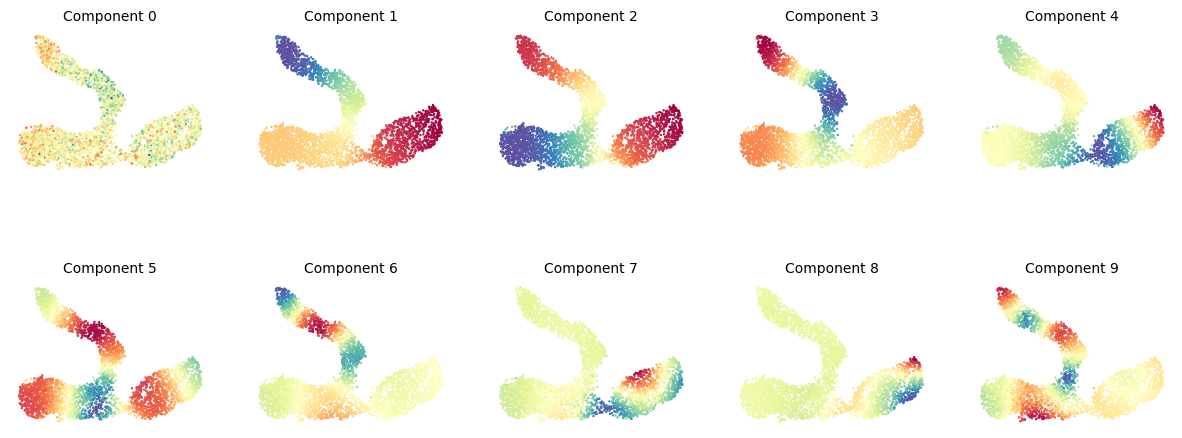

In [94]:
#visualization by diffusion map from palantir
palantir.plot.plot_diffusion_components(adata)
plt.show()

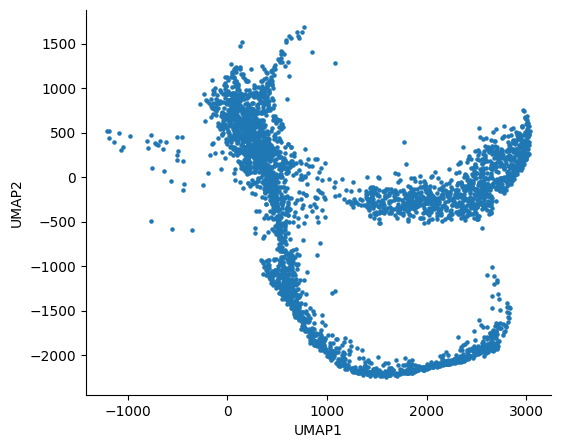

In [95]:
import matplotlib.pyplot as plt

coords = adata.obsm['X_spring']

plt.figure(figsize=(6, 5))
plt.scatter(coords[:, 0], coords[:, 1], s=5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

# 关键：确保刻度显示
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(False)  # 可选

plt.show()


In [97]:
from scipy.spatial import cKDTree

coords = adata.obsm['X_spring']
tree = cKDTree(coords)

def find_cell(x, y):
    dist, idx = tree.query([x, y])
    print("Closest cell:", adata.obs_names[idx])
    print("Distance:", dist)

# 把点击得到的坐标填进去
find_cell(3000, -2000)

Closest cell: cell33782
Distance: 297.78423547931476


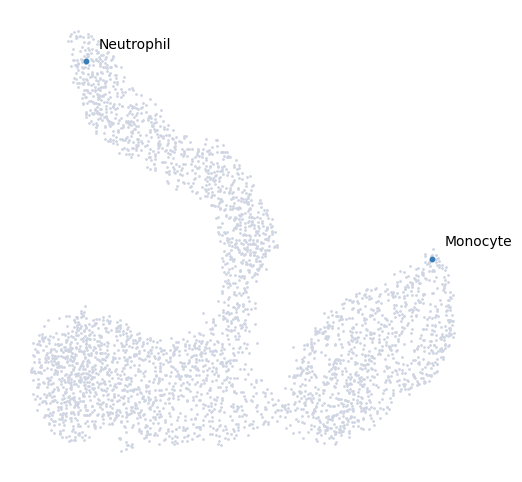

In [98]:
#choose ancestor & descendant

terminal_states = pd.Series(
    ["Neutrophil", "Monocyte"],
    index=["cell33782", "cell117001"],
)

start_cell = "cell56069"
palantir.plot.highlight_cells_on_umap(adata, terminal_states)
plt.show()


In [99]:
# palantir core fucntion
pr_res = palantir.core.run_palantir(
    adata, start_cell, num_waypoints=1200, terminal_states=terminal_states,n_jobs=-1
)

f:\Software\ANACONDA\envs\WJY\lib\site-packages\sklearn\utils\validation.py:757: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
f:\Software\ANACONDA\envs\WJY\lib\site-packages\sklearn\utils\validation.py:595: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
f:\Software\ANACONDA\envs\WJY\lib\site-packages\sklearn\utils\validation.py:604: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
f:\Software\ANACONDA\envs\WJY\lib\site-packages\sklearn\utils\validation.py:757: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.Sparse

Sampling and flocking waypoints...
Time for determining waypoints: 0.0030353307723999024 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.21608904202779133 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...


f:\Software\ANACONDA\envs\WJY\lib\site-packages\sklearn\utils\validation.py:757: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
f:\Software\ANACONDA\envs\WJY\lib\site-packages\sklearn\utils\validation.py:595: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
f:\Software\ANACONDA\envs\WJY\lib\site-packages\sklearn\utils\validation.py:604: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
f:\Software\ANACONDA\envs\WJY\lib\site-packages\sklearn\utils\validation.py:757: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.Sparse

Project results to all cells...


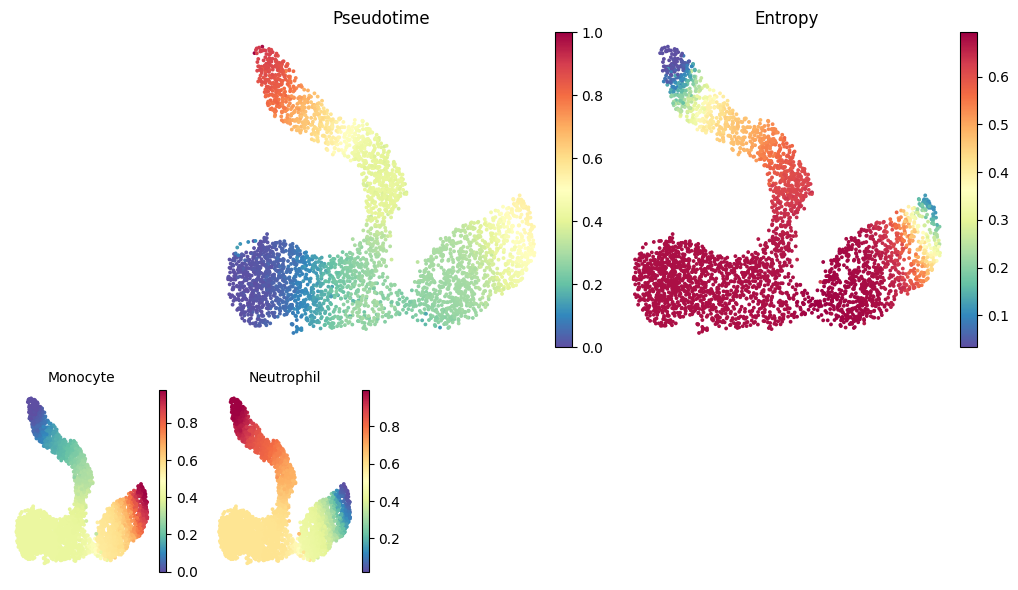

In [100]:
palantir.plot.plot_palantir_results(adata, s=3)
plt.show()

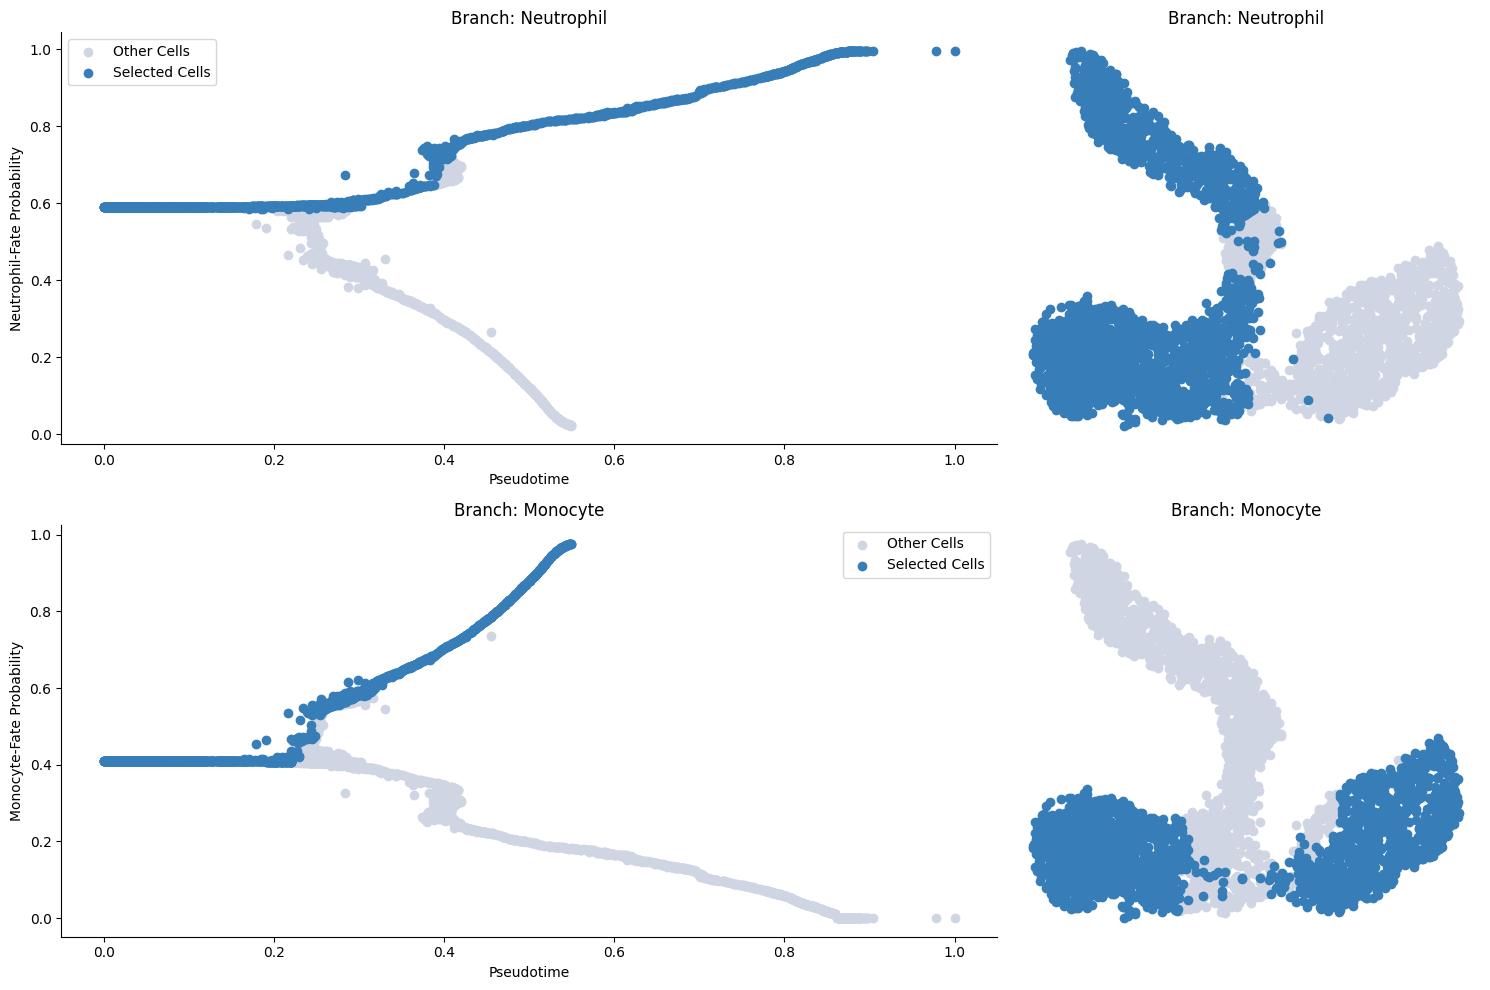

In [101]:
masks = palantir.presults.select_branch_cells(adata, q=.01, eps=.01)
palantir.plot.plot_branch_selection(adata)
plt.show()


[2026-04-14 14:57:33,972] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (2,000) and rank = 1.0.
[2026-04-14 14:57:33,973] [INFO    ] Using covariance function Matern52(ls=1.0215912818908692).
[2026-04-14 14:57:34,020] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-04-14 14:57:34,592] [INFO    ] Sigma interpreted as element-wise standard deviation.


<Axes: title={'center': 'Branch: Monocyte'}>

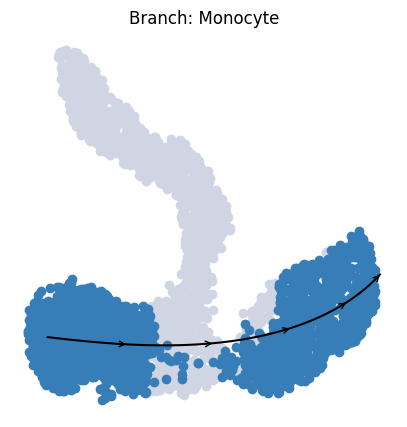

In [102]:
palantir.plot.plot_trajectory(adata, "Monocyte")

In [103]:
fate = pr_res.branch_probs
adata.obs['Monocyte_fate'] = fate['Monocyte']
adata.obs['Neutrophil_fate'] = fate['Neutrophil']
adata.obs['fate_bias'] = fate['Monocyte']/(fate['Monocyte'] + fate['Neutrophil'])


In [104]:
# extract fate bias and ground truth
adata_obs_subset = adata.obs.loc[:, ['ground_truth', 'fate_bias','Cell.type.annotation']]

# extract undifferentiated cells
adata_obs_subset_undiff = adata_obs_subset[adata_obs_subset['Cell.type.annotation'] == 'Undifferentiated']

In [105]:
adata_obs_subset_undiff.to_csv('D:/scLT/Weinreb/0814/desc246.1/palantir.res.csv')

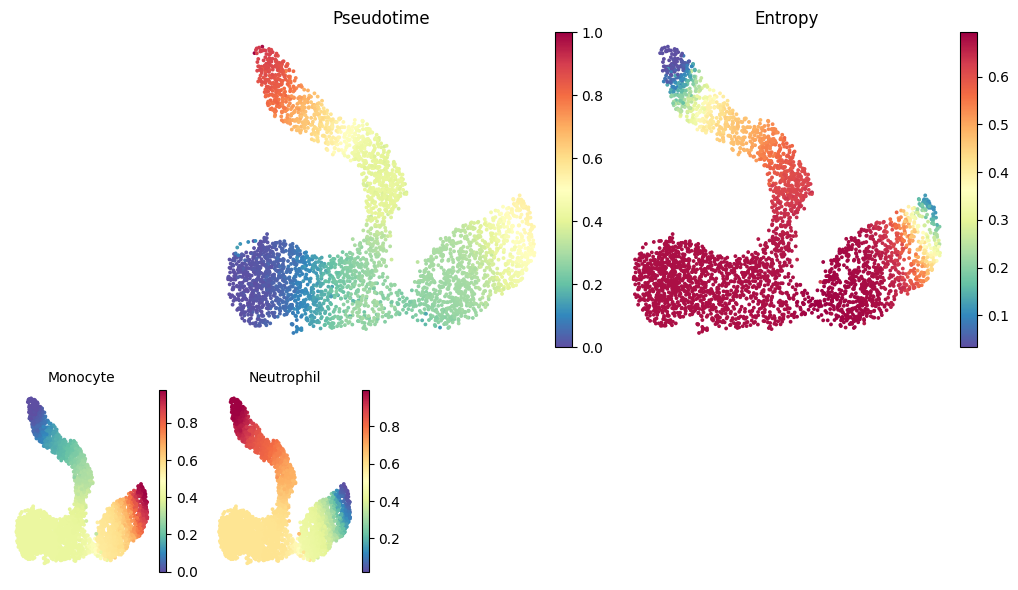

In [106]:
palantir.plot.plot_palantir_results(adata, s=3)
plt.show()

In [108]:
adata.obs['palantir_pseudotime'] = pr_res.pseudotime

In [109]:
adata.write('D:/scLT/Weinreb/0814/desc246.1/anndata2cellrank.h5ad')